# Lab 1 — Undersampling and Oversampling on DINOv2 Embeddings

**Dataset:** Kaggle `kmader/skin-cancer-mnist-ham10000` (HAM10000), binary classification (melanoma vs rest)
**Artificial imbalance:** 1:50 on the train split only, applied *after* a lesion-aware `GroupShuffleSplit`; valid/test stay at HAM10000's natural ~1:8 prevalence

Compares undersampling (`RandomUnderSampler`, `NearMiss-1`), oversampling (`SMOTE`, `KMeansSMOTE`), and cost-sensitive learning (LogReg `class_weight='balanced'`, XGBoost `scale_pos_weight`) against a no-rebalancing baseline and a majority-class dummy. Three classifiers (LogReg / small MLP / XGBoost) cover the linear / neural / tree-ensemble axes. Section 10 repeats the sweep at HAM10000's natural ratio to test whether the conclusions hold.

## 1. Setup

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import GroupShuffleSplit
import umap

from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.over_sampling import SMOTE, KMeansSMOTE

import xgboost as xgb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

LAB_ROOT = Path.cwd()
EMBED_DIR = LAB_ROOT / 'embeddings'
EMBED_DIR.mkdir(exist_ok=True)

print(f'LAB_ROOT  = {LAB_ROOT}')
print(f'EMBED_DIR = {EMBED_DIR}')

/home/pavel_henitsoi_receptor_ai/UDPM-labs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LAB_ROOT  = /home/pavel_henitsoi_receptor_ai/UDPM-labs/lab1-imbalance
EMBED_DIR = /home/pavel_henitsoi_receptor_ai/UDPM-labs/lab1-imbalance/embeddings


In [2]:
# Auto-detect best available device: CUDA -> MPS (Apple Silicon) -> CPU.
if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'device = {device}')
print(f'torch   = {torch.__version__}')
if device.type == 'cuda':
    print(f'  GPU   = {torch.cuda.get_device_name(0)}')
    print(f'  CUDA  = {torch.version.cuda}')
elif device.type == 'mps':
    print('  NOTE: MPS - DINOv2 forward pass ~20-30 min for the full dataset.')
elif device.type == 'cpu':
    print('  WARNING: CPU-only - DINOv2 forward pass will take ~1-2h.')

device = cuda
torch   = 2.6.0+cu124
  GPU   = Tesla T4
  CUDA  = 12.4


## 2. Dataset acquisition — HAM10000 with lesion-aware split

We use the canonical HAM10000 dermoscopy dataset directly (via `kmader/skin-cancer-mnist-ham10000`) rather than the DermMel mirror. HAM10000 ships a `lesion_id` column that lets us split by lesion, so different captures of the same physical lesion can never straddle train/valid/test. This is the leakage path the DermMel-augmented dataset doesn't address.

In [3]:
import kagglehub

ds_path = Path(kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000'))
print(f'Dataset downloaded to: {ds_path}')

# Images split across two part dirs; metadata is the single CSV with lesion_id.
IMG_DIRS = [ds_path / 'HAM10000_images_part_1', ds_path / 'HAM10000_images_part_2']
META_CSV = ds_path / 'HAM10000_metadata.csv'

assert all(d.is_dir() for d in IMG_DIRS), f'Missing image dirs: {IMG_DIRS}'
assert META_CSV.exists(), f'Missing metadata: {META_CSV}'
print(f'Image dirs: {[d.name for d in IMG_DIRS]}')
print(f'Metadata:   {META_CSV.name}')

Dataset downloaded to: /home/pavel_henitsoi_receptor_ai/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2
Image dirs: ['HAM10000_images_part_1', 'HAM10000_images_part_2']
Metadata:   HAM10000_metadata.csv


In [4]:
meta = pd.read_csv(META_CSV)
print(f'Metadata: {len(meta)} rows, {meta["lesion_id"].nunique()} unique lesions')
print('\nDiagnostic class counts:')
print(meta['dx'].value_counts())

# Binary task: melanoma vs everything else.
meta['label'] = (meta['dx'] == 'mel').astype(int)

# Locate each image on disk (split across two part directories).
img_lookup = {p.stem: str(p) for d in IMG_DIRS for p in d.iterdir() if p.suffix.lower() == '.jpg'}
meta['filepath'] = meta['image_id'].map(img_lookup)
assert meta['filepath'].notna().all(), f"{meta['filepath'].isna().sum()} image_ids missing on disk"

# Lesion-aware split: groups=lesion_id ensures every capture of one lesion
# lands in exactly one split. Same seed for reproducibility.
# Step 1: hold out 30% (will be split into valid + test).
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, holdout_idx = next(gss1.split(meta, groups=meta['lesion_id']))
# Step 2: split the 30% holdout into valid (15%) + test (15%).
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
holdout_meta = meta.iloc[holdout_idx].reset_index(drop=False)
valid_rel, test_rel = next(gss2.split(holdout_meta, groups=holdout_meta['lesion_id']))
valid_idx = holdout_meta.iloc[valid_rel]['index'].values
test_idx  = holdout_meta.iloc[test_rel]['index'].values

meta['split'] = 'train'
meta.loc[valid_idx, 'split'] = 'valid'
meta.loc[test_idx, 'split']  = 'test'

# Defensive: no lesion may appear in more than one split.
straddle = meta.groupby('lesion_id')['split'].nunique().max()
assert straddle == 1, f'Lesion-aware split leaked: {straddle} splits for some lesion_id'

df = meta[['filepath', 'label', 'split']].reset_index(drop=True)
print()
print(df.groupby(['split', 'label']).size().unstack(fill_value=0))
assert (df.groupby('split')['label'].nunique() == 2).all(), 'Each split needs both classes.'
assert len(df) > 9000, f'Expected ~10k images, got {len(df)}'

Metadata: 10015 rows, 7470 unique lesions

Diagnostic class counts:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

label     0    1
split           
test   1307  187
train  6232  770
valid  1363  156


## 3. Artificial imbalance (train only)

Subsample melanoma in **train** to 1:50 against not-melanoma. **valid** and **test** are left at natural distribution so per-class metrics on the test set remain statistically reliable. Imbalance is applied **after** the lesion-aware split, so a) leakage stays prevented and b) the imbalance step never accidentally drops the only image of a lesion that's already in valid/test.

In [5]:
TARGET_RATIO = 50  # not-melanoma : melanoma in training set

# Idempotent: stash an unmutated copy on first run so re-executing this cell
# always starts from the natural distribution, not from an already-imbalanced df.
if 'df_raw' not in dir():
    df_raw = df.copy()
df = df_raw.copy()

rng = np.random.default_rng(SEED)
train_mask = df['split'] == 'train'
train_neg = df[train_mask & (df['label'] == 0)]
train_pos = df[train_mask & (df['label'] == 1)]

n_pos_keep = max(6, len(train_neg) // TARGET_RATIO)  # >=6 so SMOTE k_neighbors=5 works
keep_idx = rng.choice(train_pos.index.values, size=n_pos_keep, replace=False)
drop_idx = train_pos.index.difference(pd.Index(keep_idx))
df = df.drop(index=drop_idx).reset_index(drop=True)

print('After imbalancing (train):')
print(df[df['split'] == 'train'].groupby('label').size().rename({0: 'NotMelanoma', 1: 'Melanoma'}))
n_neg_train = int((df[df['split'] == 'train']['label'] == 0).sum())
print(f'\nActual ratio: 1 : {n_neg_train // n_pos_keep}')
assert (df[df['split'] == 'train']['label'] == 1).sum() == n_pos_keep
assert n_neg_train / n_pos_keep > 40, 'Imbalance ratio collapsed'

After imbalancing (train):
label
NotMelanoma    6232
Melanoma        124
dtype: int64

Actual ratio: 1 : 50


## 4. Visualization

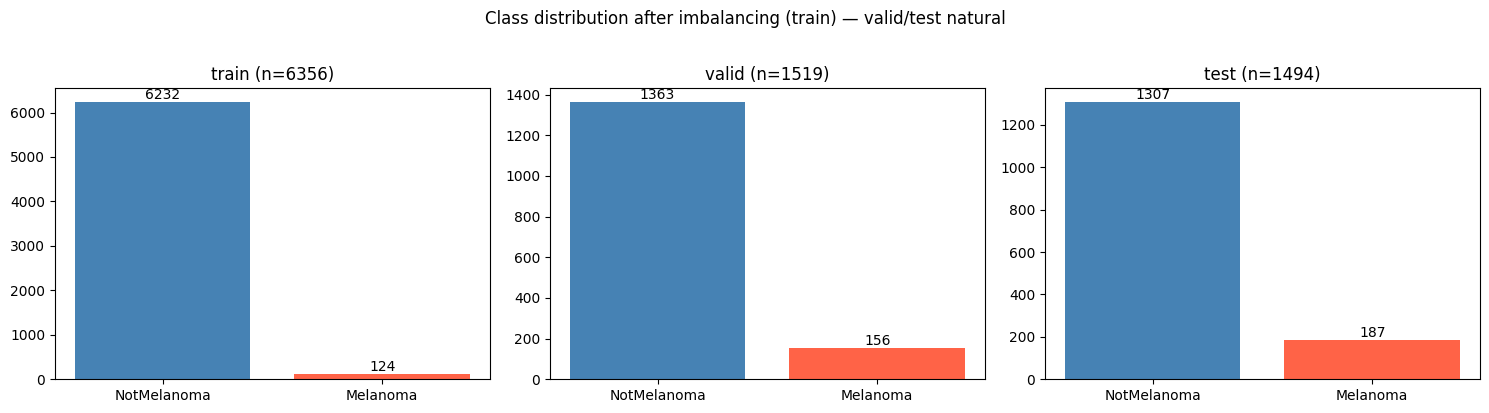

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, split in zip(axes, ['train', 'valid', 'test']):
    counts = df[df['split'] == split].groupby('label').size()
    counts.index = counts.index.map({0: 'NotMelanoma', 1: 'Melanoma'})
    ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'{split} (n={counts.sum()})')
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom')
fig.suptitle('Class distribution after imbalancing (train) — valid/test natural', y=1.02)
fig.tight_layout()
plt.show()

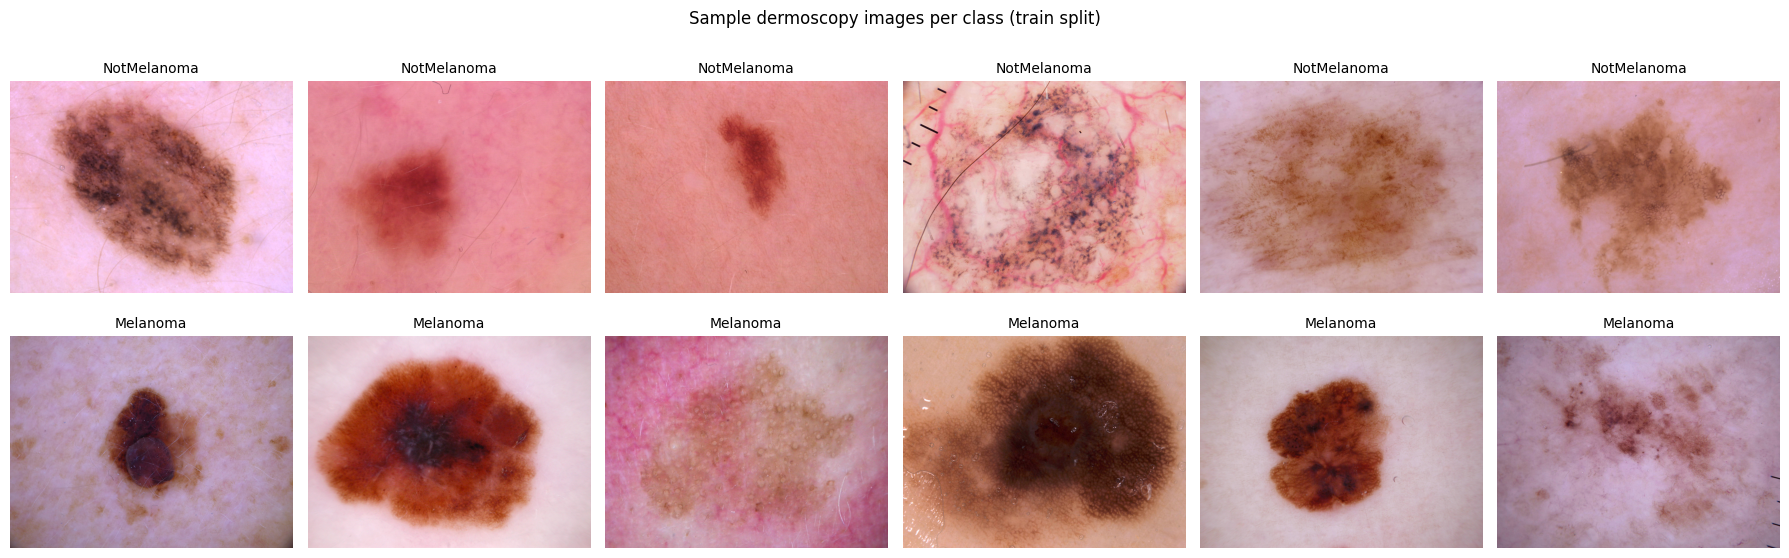

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for row_idx, (class_label, class_name) in enumerate([(0, 'NotMelanoma'), (1, 'Melanoma')]):
    sample = df[(df['split'] == 'train') & (df['label'] == class_label)].sample(6, random_state=SEED)
    for ax, fp in zip(axes[row_idx], sample['filepath']):
        img = Image.open(fp).convert('RGB')
        ax.imshow(img)
        ax.set_title(class_name, fontsize=10)
        ax.axis('off')
fig.suptitle('Sample dermoscopy images per class (train split)')
fig.tight_layout()
plt.show()

## 5. Feature extraction — DINOv2 ViT-B/14

Frozen, self-supervised features (768-dim CLS token). Cached to `embeddings/*.npz` so re-runs are fast.

In [8]:
dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', trust_repo=True)
# .train(False) is the same as PyTorch's eval-mode toggle — switches BN/Dropout to inference behavior.
dino = dino.to(device).train(False)
for p in dino.parameters():
    p.requires_grad_(False)

embed_dim = 768  # DINOv2 ViT-B
print(f'DINOv2 loaded — params: {sum(p.numel() for p in dino.parameters()) / 1e6:.1f}M, embed_dim = {embed_dim}')

Using cache found in /home/pavel_henitsoi_receptor_ai/.cache/torch/hub/facebookresearch_dinov2_main
/home/pavel_henitsoi_receptor_ai/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/pavel_henitsoi_receptor_ai/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/pavel_henitsoi_receptor_ai/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded — params: 86.6M, embed_dim = 768


In [9]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MelanomaDataset(Dataset):
    def __init__(self, rows: pd.DataFrame, transform):
        self.rows = rows.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        return self.transform(img), int(row['label'])

In [10]:
@torch.inference_mode()
def extract_embeddings(rows: pd.DataFrame, batch_size: int = 64) -> tuple[np.ndarray, np.ndarray]:
    ds = MelanomaDataset(rows, preprocess)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    feats, labels = [], []
    for imgs, ys in tqdm(dl, desc='DINOv2 forward'):
        imgs = imgs.to(device, non_blocking=True)
        z = dino(imgs)
        feats.append(z.cpu().numpy())
        labels.append(ys.numpy())
    return np.concatenate(feats), np.concatenate(labels)


def cache_split(split: str) -> tuple[np.ndarray, np.ndarray]:
    cache_path = EMBED_DIR / f'{split}.npz'
    if cache_path.exists():
        d = np.load(cache_path)
        print(f'  loaded cache: {cache_path}  X={d["X"].shape}  y={d["y"].shape}')
        return d['X'], d['y']
    rows = df[df['split'] == split]
    X, y = extract_embeddings(rows)
    np.savez_compressed(cache_path, X=X, y=y)
    print(f'  saved cache: {cache_path}  X={X.shape}  y={y.shape}')
    return X, y


print('=== train ===')
X_train, y_train = cache_split('train')
print('=== valid ===')
X_valid, y_valid = cache_split('valid')
print('=== test ===')
X_test, y_test = cache_split('test')

assert X_train.shape[1] == embed_dim
assert X_train.shape[0] == (df['split'] == 'train').sum()
print(f'\nTrain: {X_train.shape}, class counts: {np.bincount(y_train)}')
print(f'Valid: {X_valid.shape}, class counts: {np.bincount(y_valid)}')
print(f'Test:  {X_test.shape}, class counts: {np.bincount(y_test)}')

=== train ===
  loaded cache: /home/pavel_henitsoi_receptor_ai/UDPM-labs/lab1-imbalance/embeddings/train.npz  X=(6356, 768)  y=(6356,)


=== valid ===
  loaded cache: /home/pavel_henitsoi_receptor_ai/UDPM-labs/lab1-imbalance/embeddings/valid.npz  X=(1519, 768)  y=(1519,)
=== test ===
  loaded cache: /home/pavel_henitsoi_receptor_ai/UDPM-labs/lab1-imbalance/embeddings/test.npz  X=(1494, 768)  y=(1494,)

Train: (6356, 768), class counts: [6232  124]
Valid: (1519, 768), class counts: [1363  156]
Test:  (1494, 768), class counts: [1307  187]


## 6. Embedding-space EDA

PCA (linear), UMAP (nonlinear, fast), and t-SNE (nonlinear, slower). Correlation summary on a feature subset (full 768x768 matrix is unreadable).

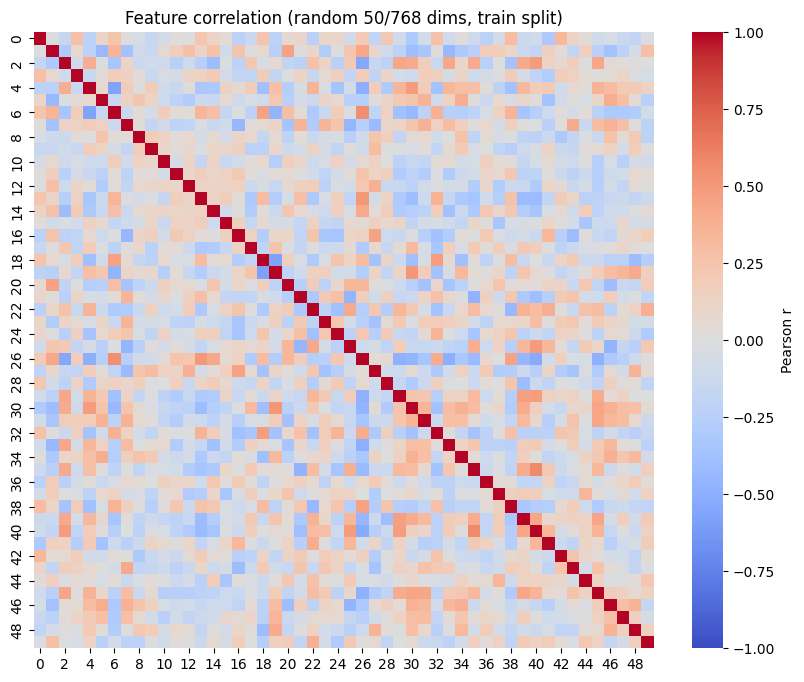

Off-diagonal |r| mean = 0.167
Off-diagonal |r| max  = 0.581


In [11]:
rng = np.random.default_rng(SEED)
dims = rng.choice(embed_dim, size=50, replace=False)
corr = np.corrcoef(X_train[:, dims].T)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'})
ax.set_title(f'Feature correlation (random 50/{embed_dim} dims, train split)')
plt.show()

tri = np.triu_indices(50, k=1)
print(f'Off-diagonal |r| mean = {np.abs(corr[tri]).mean():.3f}')
print(f'Off-diagonal |r| max  = {np.abs(corr[tri]).max():.3f}')

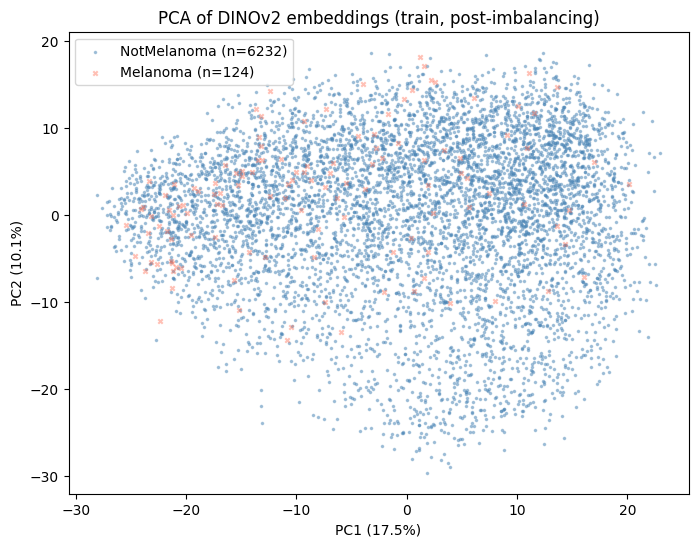

In [12]:
pca = PCA(n_components=2, random_state=SEED)
Z_pca = pca.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, name, c, m in [(0, 'NotMelanoma', 'steelblue', '.'), (1, 'Melanoma', 'tomato', 'x')]:
    sel = y_train == lbl
    ax.scatter(Z_pca[sel, 0], Z_pca[sel, 1], c=c, marker=m,
               label=f'{name} (n={sel.sum()})', alpha=0.4, s=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA of DINOv2 embeddings (train, post-imbalancing)')
ax.legend()
plt.show()

In [13]:
def stratified_subsample(X, y, n_per_class: int) -> tuple[np.ndarray, np.ndarray]:
    rng_local = np.random.default_rng(SEED)
    idx_list = []
    for lbl in np.unique(y):
        cls_idx = np.where(y == lbl)[0]
        take = min(n_per_class, len(cls_idx))
        idx_list.append(rng_local.choice(cls_idx, size=take, replace=False))
    idx = np.concatenate(idx_list)
    rng_local.shuffle(idx)
    return X[idx], y[idx]

# n_per_class capped at the minority count so UMAP/t-SNE viz shows roughly balanced classes
# (otherwise majority swamps the plot at 1:50).
X_sub, y_sub = stratified_subsample(X_train, y_train, n_per_class=int(y_train.sum()) * 2)
print(f'Subsampled for UMAP/t-SNE: {X_sub.shape}, counts: {np.bincount(y_sub)}')

Subsampled for UMAP/t-SNE: (372, 768), counts: [248 124]


/home/pavel_henitsoi_receptor_ai/UDPM-labs/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


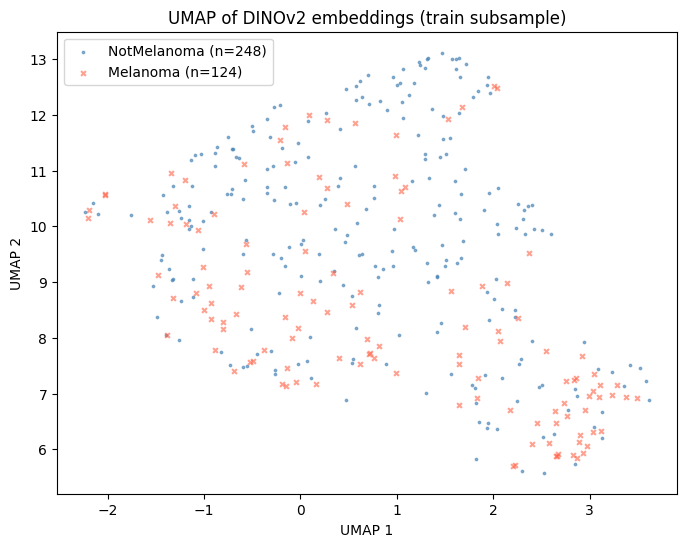

In [14]:
um = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED, metric='cosine')
Z_um = um.fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, name, c, m in [(0, 'NotMelanoma', 'steelblue', '.'), (1, 'Melanoma', 'tomato', 'x')]:
    sel = y_sub == lbl
    ax.scatter(Z_um[sel, 0], Z_um[sel, 1], c=c, marker=m,
               label=f'{name} (n={sel.sum()})', alpha=0.6, s=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of DINOv2 embeddings (train subsample)')
ax.legend()
plt.show()

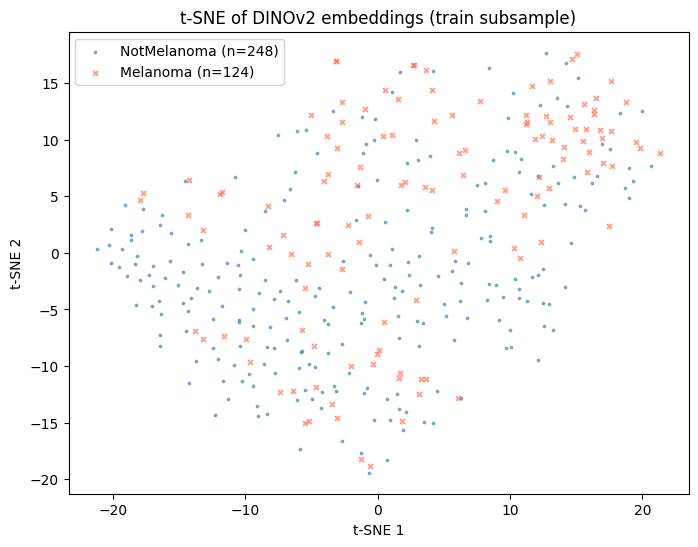

In [15]:
ts = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca', learning_rate='auto')
Z_ts = ts.fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, name, c, m in [(0, 'NotMelanoma', 'steelblue', '.'), (1, 'Melanoma', 'tomato', 'x')]:
    sel = y_sub == lbl
    ax.scatter(Z_ts[sel, 0], Z_ts[sel, 1], c=c, marker=m,
               label=f'{name} (n={sel.sum()})', alpha=0.6, s=12)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE of DINOv2 embeddings (train subsample)')
ax.legend()
plt.show()

**Observation:** DINOv2 features (self-supervised, no melanoma-specific training) already partially separate the classes. Most of the structure visible in UMAP / t-SNE is texture and color rather than diagnostic content — useful as a starting point, not a solved problem.

## 7. Model bench

Three classifiers (LogReg / MLP / XGBoost) trained on every (resampling) configuration. Helpers below: MLP training loop, unified `evaluate()`, and `run_logreg / run_mlp / run_xgb` wrappers.

In [16]:
class MLPHead(nn.Module):
    def __init__(self, in_dim: int = 768, hidden: int = 256, n_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    *, epochs: int = 30, batch_size: int = 256, lr: float = 1e-3, wd: float = 1e-4,
    patience: int = 5, seed: int = SEED,
) -> MLPHead:
    torch.manual_seed(seed)
    model = MLPHead(in_dim=X_tr.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    Xt = torch.from_numpy(X_tr).float()
    yt = torch.from_numpy(y_tr).long()
    Xv = torch.from_numpy(X_val).float().to(device)
    yv = torch.from_numpy(y_val).long().to(device)

    best_bal_acc, best_state, since_best = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train(True)
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), batch_size):
            idx = perm[i : i + batch_size]
            xb = Xt[idx].to(device, non_blocking=True)
            yb = yt[idx].to(device, non_blocking=True)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        model.train(False)  # eval-mode toggle
        with torch.inference_mode():
            preds = model(Xv).argmax(dim=1)
        bal = balanced_accuracy_score(yv.cpu().numpy(), preds.cpu().numpy())
        if bal > best_bal_acc:
            best_bal_acc = bal
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            since_best = 0
        else:
            since_best += 1
            if since_best >= patience:
                break

    model.load_state_dict(best_state)
    model.train(False)
    return model

In [17]:
def evaluate(
    name: str, classifier: str, sampling: str,
    y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray | None,
) -> dict:
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    out = {
        'run': name, 'classifier': classifier, 'sampling': sampling,
        'accuracy': report['accuracy'],
        'precision_neg': report['0']['precision'],
        'recall_neg':    report['0']['recall'],
        'f1_neg':        report['0']['f1-score'],
        'precision_pos': report['1']['precision'],
        'recall_pos':    report['1']['recall'],
        'f1_pos':        report['1']['f1-score'],
        'balanced_acc':  balanced_accuracy_score(y_true, y_pred),
        'mcc':           matthews_corrcoef(y_true, y_pred),
        'kappa':         cohen_kappa_score(y_true, y_pred),
    }
    if y_proba is not None:
        out['roc_auc'] = roc_auc_score(y_true, y_proba)
        out['pr_auc']  = average_precision_score(y_true, y_proba)
    else:
        out['roc_auc'] = float('nan')
        out['pr_auc']  = float('nan')
    return out

In [18]:
def run_logreg(X_tr, y_tr, *, class_weight=None) -> tuple[np.ndarray, np.ndarray]:
    clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight=class_weight)
    clf.fit(X_tr, y_tr)
    return clf.predict(X_test), clf.predict_proba(X_test)[:, 1]


def run_mlp(X_tr, y_tr) -> tuple[np.ndarray, np.ndarray]:
    model = train_mlp(X_tr, y_tr, X_valid, y_valid)
    with torch.inference_mode():
        logits = model(torch.from_numpy(X_test).float().to(device))
        proba = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        pred = logits.argmax(dim=1).cpu().numpy()
    return pred, proba


def run_xgb(X_tr, y_tr, *, scale_pos_weight=None) -> tuple[np.ndarray, np.ndarray]:
    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric='aucpr', early_stopping_rounds=20,
        scale_pos_weight=scale_pos_weight if scale_pos_weight else 1.0,
        random_state=SEED, tree_method='hist',
        device=('cuda' if device.type == 'cuda' else 'cpu'),
        verbosity=0,
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_valid, y_valid)], verbose=False)
    return clf.predict(X_test), clf.predict_proba(X_test)[:, 1]

### 7.1-7.3 Baselines + cost-sensitive variants

In [19]:
results: list[dict] = []
# Cache (pred, proba) per run so we don't retrain models for downstream viz.
predictions: dict[str, tuple] = {}

# Dummy (always majority)
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED).fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
predictions['dummy'] = (dummy_pred, None)
results.append(evaluate('dummy', 'Dummy', 'most_frequent', y_test, dummy_pred, None))

# Bare baselines (no rebalancing)
pred, proba = run_logreg(X_train, y_train)
predictions['bare_logreg'] = (pred, proba)
results.append(evaluate('bare_logreg', 'LogReg', 'none', y_test, pred, proba))

pred, proba = run_mlp(X_train, y_train)
predictions['bare_mlp'] = (pred, proba)
results.append(evaluate('bare_mlp', 'MLP', 'none', y_test, pred, proba))

pred, proba = run_xgb(X_train, y_train)
predictions['bare_xgb'] = (pred, proba)
results.append(evaluate('bare_xgb', 'XGBoost', 'none', y_test, pred, proba))

# Cost-sensitive (no resampling, just reweighting)
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pw = n_neg / n_pos
print(f'n_neg={n_neg}, n_pos={n_pos}, scale_pos_weight={scale_pw:.1f}')
assert n_pos >= 6, 'SMOTE k_neighbors=5 needs at least 6 minority samples'

pred, proba = run_logreg(X_train, y_train, class_weight='balanced')
predictions['cw_logreg'] = (pred, proba)
results.append(evaluate('cw_logreg', 'LogReg', 'class_weight', y_test, pred, proba))

pred, proba = run_xgb(X_train, y_train, scale_pos_weight=scale_pw)
predictions['spw_xgb'] = (pred, proba)
results.append(evaluate('spw_xgb', 'XGBoost', 'scale_pos_weight', y_test, pred, proba))

pd.DataFrame(results).round(3)

n_neg=6232, n_pos=124, scale_pos_weight=50.3


,run,classifier,sampling,accuracy,precision_neg,recall_neg,f1_neg,precision_pos,recall_pos,f1_pos,balanced_acc,mcc,kappa,roc_auc,pr_auc
0,dummy,Dummy,most_frequent,0.875,0.875,1.000,0.933,0.000,0.000,0.000,0.500,0.000,0.000,NaN,NaN
1,bare_logreg,LogReg,none,0.883,0.890,0.988,0.937,0.636,0.150,0.242,0.569,0.269,0.204,0.809,0.461
2,bare_mlp,MLP,none,0.875,0.875,1.000,0.933,0.000,0.000,0.000,0.500,0.000,0.000,0.695,0.223
3,bare_xgb,XGBoost,none,0.876,0.876,1.000,0.934,1.000,0.011,0.021,0.505,0.097,0.019,0.808,0.450
4,cw_logreg,LogReg,class_weight,0.880,0.903,0.966,0.933,0.537,0.273,0.362,0.620,0.324,0.303,0.802,0.449
5,spw_xgb,XGBoost,scale_pos_weight,0.880,0.881,0.998,0.936,0.833,0.053,0.101,0.526,0.193,0.087,0.809,0.440


### 7.4 Sampling sweep — 4 methods × 3 classifiers = 12 runs

In [20]:
samplers = {
    'RandomUnder': RandomUnderSampler(random_state=SEED),
    'NearMiss-1':  NearMiss(version=1),
    'SMOTE':       SMOTE(k_neighbors=5, random_state=SEED),
    'KMeansSMOTE': KMeansSMOTE(
        k_neighbors=5, random_state=SEED,
        # Few large clusters + zero threshold so every cluster qualifies.
        # Required at 1:50 imbalance - default config dilutes ~106 minority
        # samples across 8 clusters and rejects every one.
        kmeans_estimator=4,
        cluster_balance_threshold=0.0,
    ),
}

for sname, sampler in samplers.items():
    print(f'=== {sname} ===')
    X_rs, y_rs = sampler.fit_resample(X_train, y_train)
    print(f'  resampled: {X_rs.shape}, counts: {np.bincount(y_rs)}')

    pred, proba = run_logreg(X_rs, y_rs)
    predictions[f'{sname}_logreg'] = (pred, proba)
    results.append(evaluate(f'{sname}_logreg', 'LogReg', sname, y_test, pred, proba))

    pred, proba = run_mlp(X_rs, y_rs)
    predictions[f'{sname}_mlp'] = (pred, proba)
    results.append(evaluate(f'{sname}_mlp', 'MLP', sname, y_test, pred, proba))

    pred, proba = run_xgb(X_rs, y_rs)
    predictions[f'{sname}_xgb'] = (pred, proba)
    results.append(evaluate(f'{sname}_xgb', 'XGBoost', sname, y_test, pred, proba))

results_df = pd.DataFrame(results)
print(f'\nTotal runs: {len(results_df)}')
assert len(results_df) == 18, f'Expected 18 result rows, got {len(results_df)}'
results_df.to_csv('results.csv', index=False)
print('Saved results.csv')
results_df.round(3)

=== RandomUnder ===
  resampled: (248, 768), counts: [124 124]


=== NearMiss-1 ===
  resampled: (248, 768), counts: [124 124]


=== SMOTE ===
  resampled: (12464, 768), counts: [6232 6232]


=== KMeansSMOTE ===


  resampled: (12467, 768), counts: [6232 6235]



Total runs: 18
Saved results.csv


,run,classifier,sampling,accuracy,precision_neg,recall_neg,f1_neg,precision_pos,recall_pos,f1_pos,balanced_acc,mcc,kappa,roc_auc,pr_auc
0,dummy,Dummy,most_frequent,0.875,0.875,1.000,0.933,0.000,0.000,0.000,0.500,0.000,0.000,NaN,NaN
1,bare_logreg,LogReg,none,0.883,0.890,0.988,0.937,0.636,0.150,0.242,0.569,0.269,0.204,0.809,0.461
2,bare_mlp,MLP,none,0.875,0.875,1.000,0.933,0.000,0.000,0.000,0.500,0.000,0.000,0.695,0.223
3,bare_xgb,XGBoost,none,0.876,0.876,1.000,0.934,1.000,0.011,0.021,0.505,0.097,0.019,0.808,0.450
4,cw_logreg,LogReg,class_weight,0.880,0.903,0.966,0.933,0.537,0.273,0.362,0.620,0.324,0.303,0.802,0.449
5,spw_xgb,XGBoost,scale_pos_weight,0.880,0.881,0.998,0.936,0.833,0.053,0.101,0.526,0.193,0.087,0.809,0.440
6,RandomUnder_logreg,LogReg,RandomUnder,0.726,0.947,0.728,0.823,0.273,0.717,0.396,0.722,0.313,0.262,0.799,0.360
7,RandomUnder_mlp,MLP,RandomUnder,0.619,0.956,0.592,0.731,0.221,0.807,0.347,0.700,0.265,0.187,0.774,0.345
8,RandomUnder_xgb,XGBoost,RandomUnder,0.689,0.938,0.691,0.796,0.239,0.679,0.354,0.685,0.256,0.207,0.769,0.328
9,NearMiss-1_logreg,LogReg,NearMiss-1,0.499,0.956,0.448,0.610,0.181,0.856,0.299,0.652,0.204,0.117,0.709,0.232


## 8. Evaluation

In [21]:
display_cols = [
    'classifier', 'sampling', 'accuracy', 'balanced_acc',
    'recall_pos', 'precision_pos', 'f1_pos',
    'roc_auc', 'pr_auc', 'mcc', 'kappa',
]
table = results_df[display_cols].round(3).set_index(['classifier', 'sampling'])
table.style.background_gradient(cmap='Greens', subset=['recall_pos', 'balanced_acc', 'pr_auc', 'mcc'])

,,accuracy,balanced_acc,recall_pos,precision_pos,f1_pos,roc_auc,pr_auc,mcc,kappa
classifier,sampling,,,,,,,,,
Dummy,most_frequent,0.875000,0.500000,0.000000,0.000000,0.000000,nan,nan,0.000000,0.000000
LogReg,none,0.883000,0.569000,0.150000,0.636000,0.242000,0.809000,0.461000,0.269000,0.204000
MLP,none,0.875000,0.500000,0.000000,0.000000,0.000000,0.695000,0.223000,0.000000,0.000000
XGBoost,none,0.876000,0.505000,0.011000,1.000000,0.021000,0.808000,0.450000,0.097000,0.019000
LogReg,class_weight,0.880000,0.620000,0.273000,0.537000,0.362000,0.802000,0.449000,0.324000,0.303000
XGBoost,scale_pos_weight,0.880000,0.526000,0.053000,0.833000,0.101000,0.809000,0.440000,0.193000,0.087000
LogReg,RandomUnder,0.726000,0.722000,0.717000,0.273000,0.396000,0.799000,0.360000,0.313000,0.262000
MLP,RandomUnder,0.619000,0.700000,0.807000,0.221000,0.347000,0.774000,0.345000,0.265000,0.187000
XGBoost,RandomUnder,0.689000,0.685000,0.679000,0.239000,0.354000,0.769000,0.328000,0.256000,0.207000


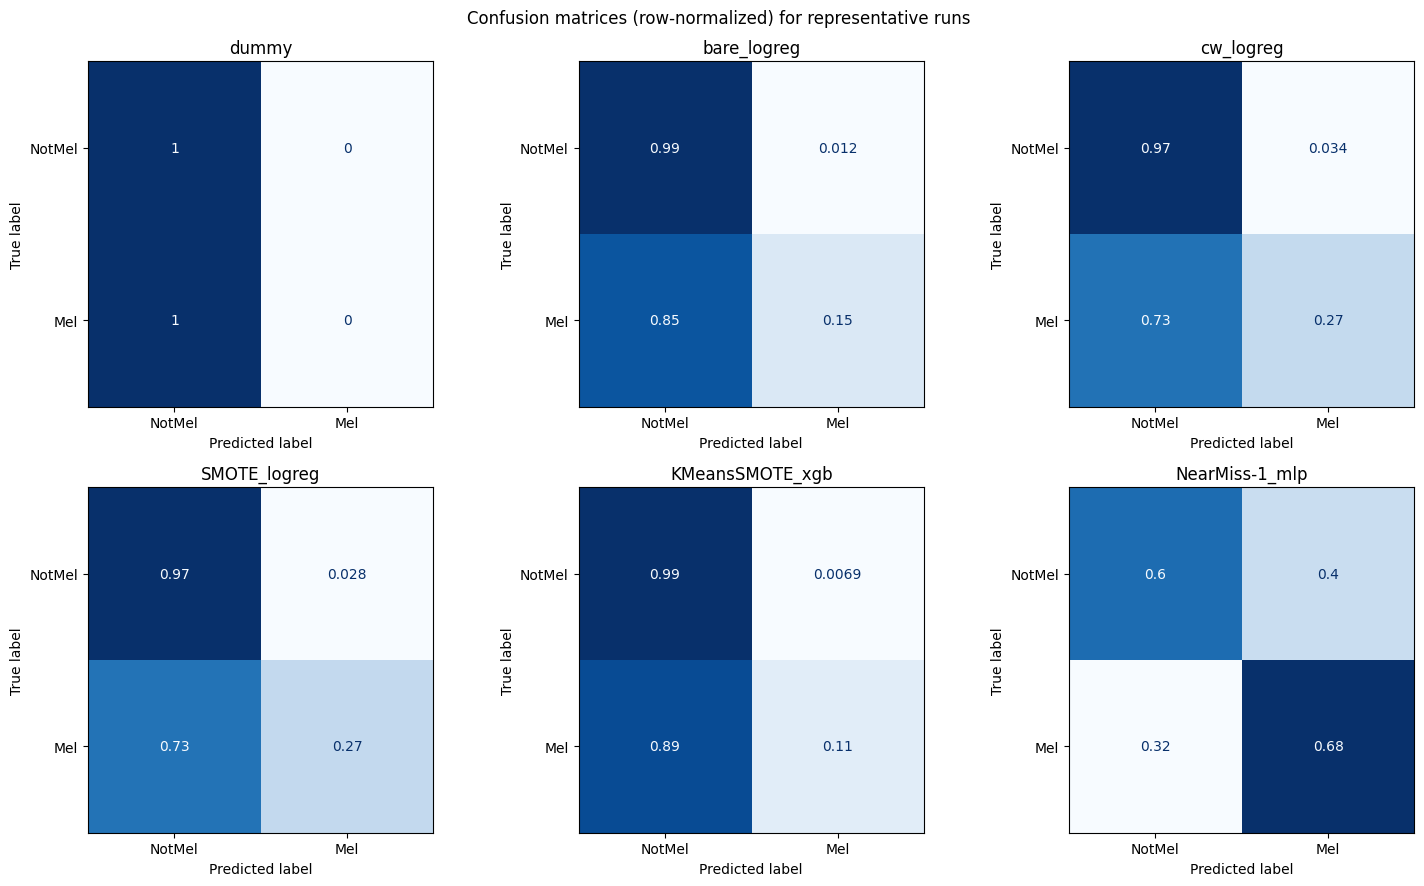

In [22]:
# Uses cached predictions - no retraining.
selected = ['dummy', 'bare_logreg', 'cw_logreg', 'SMOTE_logreg', 'KMeansSMOTE_xgb', 'NearMiss-1_mlp']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.flat, selected):
    pred = predictions[name][0]
    cm = confusion_matrix(y_test, pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=['NotMel', 'Mel']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
fig.suptitle('Confusion matrices (row-normalized) for representative runs')
fig.tight_layout()
plt.show()

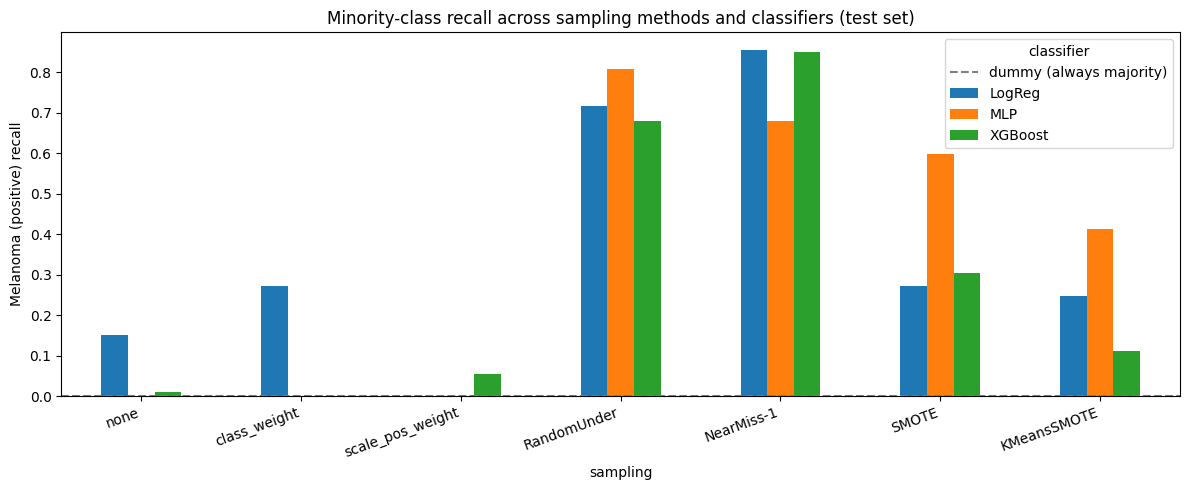

In [23]:
pivot = results_df[results_df['classifier'] != 'Dummy'].pivot_table(
    index='sampling', columns='classifier', values='recall_pos', aggfunc='first',
)
order = ['none', 'class_weight', 'scale_pos_weight', 'RandomUnder', 'NearMiss-1', 'SMOTE', 'KMeansSMOTE']
pivot = pivot.reindex([o for o in order if o in pivot.index])

ax = pivot.plot(kind='bar', figsize=(12, 5), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.axhline(results_df.loc[results_df['run'] == 'dummy', 'recall_pos'].iloc[0],
           ls='--', color='gray', label='dummy (always majority)')
ax.set_ylabel('Melanoma (positive) recall')
ax.set_title('Minority-class recall across sampling methods and classifiers (test set)')
ax.set_xticklabels(pivot.index, rotation=20, ha='right')
ax.legend(title='classifier')
plt.tight_layout()
plt.show()

## 9. Conclusions

**Dataset.** HAM10000, 10,015 images from 7,470 unique lesions, 7 diagnostic classes mapped to binary `melanoma vs not-melanoma`. Lesion-aware `GroupShuffleSplit` (70/15/15) so multi-captures of the same lesion never cross splits. Train artificially imbalanced to 1:50 (6,232 not-mel + 124 mel); valid (1,363 / 156) and test (1,307 / 187) left at natural ~12% prevalence.

**1. Do DINOv2 self-supervised features already separate melanoma from not-melanoma?**

PCA captures **27.6%** of variance in the first two components (PC1 = 17.5%, PC2 = 10.1%) and shows *partial* class separation. UMAP and t-SNE reveal a single elongated manifold with melanoma distributed along one tip but not cleanly clustered. The feature-correlation heatmap shows DINOv2 dims are largely decorrelated (mean off-diagonal |r| = 0.167, max = 0.581). Conclusion: DINOv2 carries useful ranking signal (test ROC-AUC peaks around 0.81 for the best run), but the embedding space is *not* linearly trivial — and crucially, a default-threshold classifier cannot recover minority samples at 1:50 without intervention.

**2. How badly does the no-rebalancing baseline collapse at 1:50?**

| Bare model | recall_pos | precision_pos | MCC | PR-AUC |
|---|---|---|---|---|
| Dummy (always majority) | 0.000 | 0.000 | 0.000 | – |
| LogReg | 0.150 | 0.636 | 0.269 | 0.461 |
| MLP | **0.000** | 0.000 | 0.000 | 0.223 |
| XGBoost | **0.011** | 1.000 | 0.097 | 0.450 |

At 1:50, bare MLP fully collapses to the majority class (recall_pos = 0) and bare XGBoost nearly so (recall_pos = 0.011) — they differ from the dummy mainly in their PR-AUC (the *ranking* signal is still present in the embeddings, but the 0.5 decision threshold is wrong). LogReg's L2 prior keeps it slightly off the floor but still recovers only 15% of melanomas. Class-imbalance handling is **load-bearing**, not optional, on this dataset.

**3. Within each family, does the informed variant beat the naive variant?**

- **Undersampling — RandomUnder vs NearMiss-1.** RandomUnder wins decisively. NearMiss-1 inflates recall_pos to 0.68–0.86 but tanks precision_pos to 0.16–0.19, dragging MCC to **0.15–0.20 across all three classifiers** — below most cost-sensitive baselines and well below the SMOTE/RandomUnder sweeps. The "keep majority points closest to minority" heuristic systematically over-prunes the negative-class boundary at this prevalence and leaves the classifier biased toward false positives.
- **Oversampling — SMOTE vs KMeansSMOTE.** SMOTE wins. `SMOTE_xgb` is the global best (MCC = 0.360, PR-AUC = 0.452); SMOTE beats KMeansSMOTE in 2 of 3 classifier pairings. KMeansSMOTE's cluster-then-synthesize heuristic doesn't help here — with 124 minority samples spread across 4 clusters, the synthetic points apparently land in less useful regions of the embedding space than vanilla SMOTE's k-NN interpolation.

**4. Do native cost-sensitive variants match resampling?**

- `class_weight='balanced'` LogReg: MCC = 0.324, recall_pos = 0.273 — competitive but **loses** to `SMOTE_logreg` (MCC 0.344) and `SMOTE_xgb` (0.360). For LogReg, cost-sensitive reweighting recovers most but not all of the gap.
- `scale_pos_weight` XGBoost: MCC = 0.193, recall_pos = 0.053 — recovers some ground from bare XGB (MCC 0.097) but stays well below every resampling variant. **Cost-sensitive reweighting alone is insufficient for XGBoost at 1:50.** XGBoost needs explicit resampling (SMOTE, RandomUnder, or KMeansSMOTE) to break out of the near-majority collapse. This motivates Lab 2's deeper look at cost-sensitive objectives (weighted CE and Focal Loss) on the MLP head, which has no native `class_weight` knob.

**Caveats**

- XGBoost gets an `early_stopping_rounds=20` signal from `X_valid` for tree-count selection; the MLP also early-stops on validation balanced_acc. Only LogReg trains blind to validation. Comparison is therefore fair within model family but slightly favors the models that peek at validation.
- LogReg is run at default `C=1.0` without tuning. A grid over C would likely shift absolute numbers but not the qualitative ranking.
- Single seed (42); the lab is descriptive, not inferential — no significance testing across seeds. The lab is reproducible across fresh kernels but in-session re-runs of the sweep can drift slightly because `KMeansSMOTE` carries internal KMeans state across `fit_resample` calls.
- Test prevalence (~12% melanoma) reflects HAM10000's natural distribution, which is itself biased toward dermoscopy-clinic referrals — real-world primary-care melanoma incidence is ~1%. Numbers here generalize to dermoscopy-referral settings, not to mass screening.
- Splits are lesion-aware (no multi-capture leakage), but we did **not** stratify by patient age, sex, or anatomical site — distributional shift on those axes between splits could affect absolute numbers.

**Headline takeaway**

At 1:50 imbalance on lesion-aware HAM10000 splits, **`SMOTE + XGBoost` is the single strongest combination** (MCC = 0.360, balanced_acc = 0.636); SMOTE consistently dominates the oversampling family; **bare MLP and XGBoost near-fully collapse to the majority class without intervention** — class-imbalance handling is mandatory here, not cosmetic; **`NearMiss-1` is actively harmful** — informed undersampling at high imbalance over-prunes the majority boundary and turns the classifier into a false-positive machine. Lab 2 will probe whether weighted CE or Focal Loss on the same embeddings can recover the SMOTE gap without paying SMOTE's synthetic-sample overhead — particularly important for the MLP, which has no native `class_weight` knob and needs its own cost-sensitive treatment.

## 10. Bonus comparison — natural 1:8 imbalance

The main analysis above runs at artificial 1:50, which stress-tests the imbalance methods (bare baselines collapse, methods have something dramatic to do). This bonus section reruns the same 18-experiment sweep at HAM10000's **natural** ratio (~1:8 in our lesion-aware train: 6,232 not-mel + 770 mel) for an apples-to-apples honest-distribution comparison.

Embeddings for the natural-distribution train split are cached separately (`embeddings/train_natural.npz`). Valid and test splits are identical to the main analysis, so the test-set metrics here are directly comparable.

In [24]:
# Extract embeddings for the full natural-distribution train split (no imbalancing).
nat_cache = EMBED_DIR / 'train_natural.npz'
if nat_cache.exists():
    d = np.load(nat_cache)
    X_train_nat, y_train_nat = d['X'], d['y']
    print(f'  loaded cache: {nat_cache}  X={X_train_nat.shape}  y={y_train_nat.shape}')
else:
    rows_nat = df_raw[df_raw['split'] == 'train']
    X_train_nat, y_train_nat = extract_embeddings(rows_nat)
    np.savez_compressed(nat_cache, X=X_train_nat, y=y_train_nat)
    print(f'  saved cache: {nat_cache}  X={X_train_nat.shape}  y={y_train_nat.shape}')

n_neg_nat = int((y_train_nat == 0).sum())
n_pos_nat = int((y_train_nat == 1).sum())
print(f'\nNatural train: not-mel={n_neg_nat}, mel={n_pos_nat}, ratio = 1 : {n_neg_nat/n_pos_nat:.1f}')

  loaded cache: /home/pavel_henitsoi_receptor_ai/UDPM-labs/lab1-imbalance/embeddings/train_natural.npz  X=(7002, 768)  y=(7002,)

Natural train: not-mel=6232, mel=770, ratio = 1 : 8.1


In [25]:
# Re-run the same 18 experiments on the natural-distribution train set.
results_nat = []

# Dummy
dummy_n = DummyClassifier(strategy='most_frequent', random_state=SEED).fit(X_train_nat, y_train_nat)
results_nat.append(evaluate('dummy', 'Dummy', 'most_frequent', y_test, dummy_n.predict(X_test), None))

# Bare baselines (no rebalancing)
pred, proba = run_logreg(X_train_nat, y_train_nat)
results_nat.append(evaluate('bare_logreg', 'LogReg', 'none', y_test, pred, proba))
pred, proba = run_mlp(X_train_nat, y_train_nat)
results_nat.append(evaluate('bare_mlp', 'MLP', 'none', y_test, pred, proba))
pred, proba = run_xgb(X_train_nat, y_train_nat)
results_nat.append(evaluate('bare_xgb', 'XGBoost', 'none', y_test, pred, proba))

# Cost-sensitive
spw_nat = n_neg_nat / n_pos_nat
print(f'scale_pos_weight at natural = {spw_nat:.2f}')
pred, proba = run_logreg(X_train_nat, y_train_nat, class_weight='balanced')
results_nat.append(evaluate('cw_logreg', 'LogReg', 'class_weight', y_test, pred, proba))
pred, proba = run_xgb(X_train_nat, y_train_nat, scale_pos_weight=spw_nat)
results_nat.append(evaluate('spw_xgb', 'XGBoost', 'scale_pos_weight', y_test, pred, proba))

# Fresh sampler instances — same configs as cell 30, but independent objects
# so no state from the 1:50 fits can leak into the natural-1:8 fits.
samplers_nat = {
    'RandomUnder': RandomUnderSampler(random_state=SEED),
    'NearMiss-1': NearMiss(version=1),
    'SMOTE': SMOTE(random_state=SEED),
    'KMeansSMOTE': KMeansSMOTE(random_state=SEED, kmeans_estimator=4, cluster_balance_threshold=0.0),
}
for sname, sampler in samplers_nat.items():
    print(f'=== {sname} (natural) ===')
    X_rs, y_rs = sampler.fit_resample(X_train_nat, y_train_nat)
    print(f'  resampled: {X_rs.shape}, counts: {np.bincount(y_rs)}')
    pred, proba = run_logreg(X_rs, y_rs)
    results_nat.append(evaluate(f'{sname}_logreg', 'LogReg', sname, y_test, pred, proba))
    pred, proba = run_mlp(X_rs, y_rs)
    results_nat.append(evaluate(f'{sname}_mlp', 'MLP', sname, y_test, pred, proba))
    pred, proba = run_xgb(X_rs, y_rs)
    results_nat.append(evaluate(f'{sname}_xgb', 'XGBoost', sname, y_test, pred, proba))

results_nat_df = pd.DataFrame(results_nat)
print(f'\nTotal natural runs: {len(results_nat_df)}')
assert len(results_nat_df) == 18, f'Expected 18 result rows, got {len(results_nat_df)}'
results_nat_df.to_csv('results_natural.csv', index=False)
print('Saved results_natural.csv')
results_nat_df.round(3)

/home/pavel_henitsoi_receptor_ai/UDPM-labs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


scale_pos_weight at natural = 8.09


/home/pavel_henitsoi_receptor_ai/UDPM-labs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== RandomUnder (natural) ===
  resampled: (1540, 768), counts: [770 770]


=== NearMiss-1 (natural) ===
  resampled: (1540, 768), counts: [770 770]


...

=== KMeansSMOTE (natural) ===


  resampled: (12467, 768), counts: [6232 6235]


/home/pavel_henitsoi_receptor_ai/UDPM-labs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Total natural runs: 18
Saved results_natural.csv


,run,classifier,sampling,accuracy,precision_neg,recall_neg,f1_neg,precision_pos,recall_pos,f1_pos,balanced_acc,mcc,kappa,roc_auc,pr_auc
0,dummy,Dummy,most_frequent,0.875,0.875,1.000,0.933,0.000,0.000,0.000,0.500,0.000,0.000,NaN,NaN
1,bare_logreg,LogReg,none,0.878,0.923,0.939,0.931,0.515,0.455,0.483,0.697,0.415,0.414,0.840,0.494
2,bare_mlp,MLP,none,0.894,0.916,0.967,0.941,0.623,0.380,0.472,0.673,0.432,0.416,0.873,0.573
3,bare_xgb,XGBoost,none,0.888,0.891,0.993,0.940,0.763,0.155,0.258,0.574,0.311,0.225,0.841,0.505
4,cw_logreg,LogReg,class_weight,0.811,0.942,0.836,0.886,0.358,0.642,0.460,0.739,0.379,0.356,0.834,0.467
5,spw_xgb,XGBoost,scale_pos_weight,0.857,0.917,0.920,0.919,0.429,0.417,0.423,0.669,0.341,0.341,0.824,0.448
6,RandomUnder_logreg,LogReg,RandomUnder,0.750,0.946,0.757,0.841,0.292,0.701,0.412,0.729,0.330,0.286,0.819,0.384
7,RandomUnder_mlp,MLP,RandomUnder,0.635,0.950,0.614,0.746,0.223,0.775,0.347,0.695,0.260,0.189,0.786,0.387
8,RandomUnder_xgb,XGBoost,RandomUnder,0.695,0.948,0.689,0.798,0.254,0.738,0.378,0.714,0.294,0.235,0.796,0.387
9,NearMiss-1_logreg,LogReg,NearMiss-1,0.509,0.964,0.455,0.619,0.188,0.882,0.310,0.669,0.227,0.131,0.723,0.228


In [26]:
# Side-by-side comparison: 1:50 (main analysis) vs 1:8 (natural).
cmp_cols = ['recall_pos', 'precision_pos', 'mcc', 'pr_auc']

main_subset = results_df[['run', 'classifier', 'sampling'] + cmp_cols].rename(
    columns={c: f'{c}_1to50' for c in cmp_cols}
)
nat_subset = results_nat_df[['run'] + cmp_cols].rename(columns={c: f'{c}_1to8' for c in cmp_cols})
comparison = pd.merge(main_subset, nat_subset, on='run')
comparison['mcc_delta'] = comparison['mcc_1to8'] - comparison['mcc_1to50']

# Sort by 1:50 MCC ascending so the dramatic recoveries (bare classifiers) sit at the top.
display_cmp = comparison.sort_values('mcc_1to50')[
    ['run', 'classifier', 'sampling', 'mcc_1to50', 'mcc_1to8', 'mcc_delta', 'recall_pos_1to50', 'recall_pos_1to8']
].round(3)
display_cmp

,run,classifier,sampling,mcc_1to50,mcc_1to8,mcc_delta,recall_pos_1to50,recall_pos_1to8
0,dummy,Dummy,most_frequent,0.000,0.000,0.000,0.000,0.000
2,bare_mlp,MLP,none,0.000,0.432,0.432,0.000,0.380
3,bare_xgb,XGBoost,none,0.097,0.311,0.215,0.011,0.155
11,NearMiss-1_xgb,XGBoost,NearMiss-1,0.146,0.199,0.053,0.850,0.845
10,NearMiss-1_mlp,MLP,NearMiss-1,0.183,0.235,0.052,0.679,0.952
5,spw_xgb,XGBoost,scale_pos_weight,0.193,0.341,0.149,0.053,0.417
9,NearMiss-1_logreg,LogReg,NearMiss-1,0.204,0.227,0.023,0.856,0.882
17,KMeansSMOTE_xgb,XGBoost,KMeansSMOTE,0.249,0.357,0.109,0.112,0.305
8,RandomUnder_xgb,XGBoost,RandomUnder,0.256,0.294,0.038,0.679,0.738
7,RandomUnder_mlp,MLP,RandomUnder,0.265,0.260,-0.005,0.807,0.775


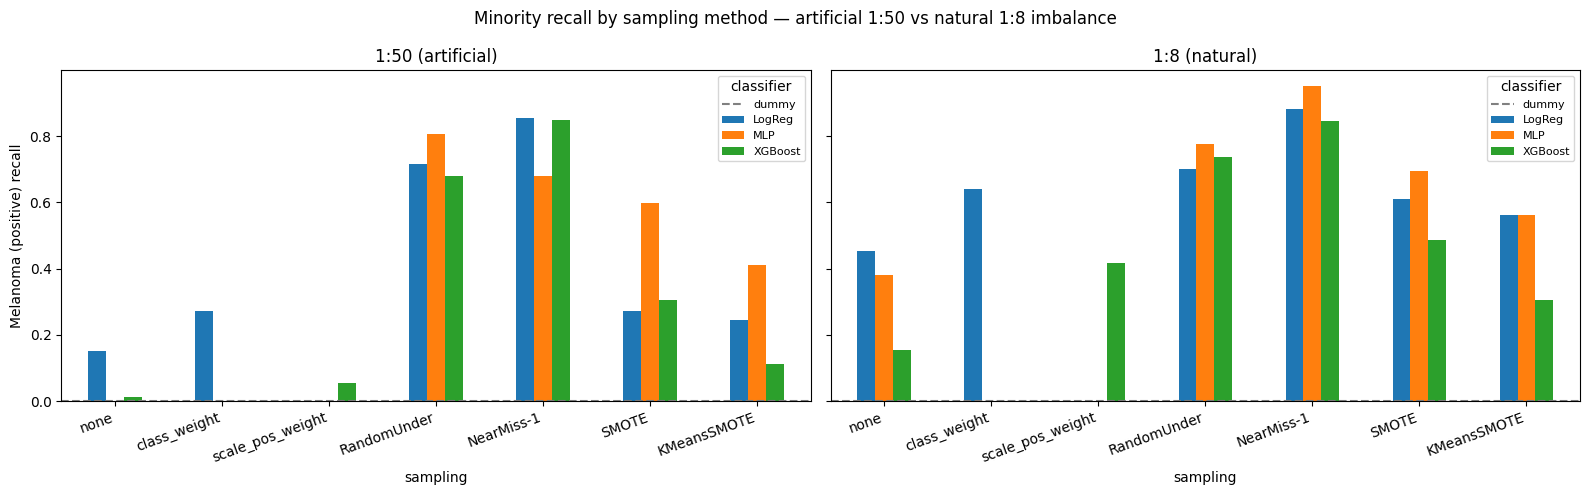

In [27]:
# Visual: per-classifier recall_pos at 1:50 vs 1:8, side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, (label, src) in zip(axes, [('1:50 (artificial)', results_df), ('1:8 (natural)', results_nat_df)]):
    pivot = src[src['classifier'] != 'Dummy'].pivot_table(
        index='sampling', columns='classifier', values='recall_pos', aggfunc='first',
    )
    order = ['none', 'class_weight', 'scale_pos_weight', 'RandomUnder', 'NearMiss-1', 'SMOTE', 'KMeansSMOTE']
    pivot = pivot.reindex([o for o in order if o in pivot.index])
    pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.axhline(src.loc[src['run'] == 'dummy', 'recall_pos'].iloc[0],
               ls='--', color='gray', label='dummy')
    ax.set_title(label)
    ax.set_ylabel('Melanoma (positive) recall')
    ax.set_xticklabels(pivot.index, rotation=20, ha='right')
    ax.legend(title='classifier', fontsize=8)
fig.suptitle('Minority recall by sampling method — artificial 1:50 vs natural 1:8 imbalance')
plt.tight_layout()
plt.show()

### 10.1 Observations — what the comparison actually shows

**Bare baselines recover dramatically at natural 1:8:**

| Bare model | MCC at 1:50 | MCC at 1:8 | Δ |
|---|---|---|---|
| LogReg | 0.269 | 0.415 | **+0.146** |
| MLP | 0.000 (collapsed) | 0.432 | **+0.432** |
| XGBoost | 0.097 (near-collapsed) | 0.311 | **+0.214** |

At natural 1:8 with 770 minority training samples, all three classifiers learn a useful decision boundary without any intervention. The "must use imbalance methods" claim is **specific to severe imbalance** — it doesn't generalize.

**No imbalance method beats the bare MLP at 1:8:**

The 1:50 winner was `SMOTE_xgb` (MCC = 0.360). At 1:8 it drops to 0.296 — *worse* than bare LogReg (0.415) and bare MLP (0.432). The new 1:8 leaderboard is led by **`bare_mlp` itself (0.432)**, followed by `KMeansSMOTE_logreg` (0.417), `bare_logreg` (0.415), `KMeansSMOTE_mlp` (0.406), `SMOTE_mlp` (0.394). The best resampler is +0.002 above bare_logreg and –0.015 below bare_mlp. Several sampling+classifier combinations (SMOTE_xgb, NearMiss-1 across all classifiers, RandomUnder_mlp) are actively *worse* than the corresponding bare classifier.

**NearMiss-1 is still bad at both ratios:**

- 1:50: MCC range 0.15–0.20 across classifiers.
- 1:8: MCC range 0.20–0.24 across classifiers.

The over-aggressive majority pruning hurts regardless of starting imbalance — confirming this is a fundamental method weakness, not an artifact of 1:50.

**Cost-sensitive variants are partial fixes at 1:50, mediocre at 1:8:**

- `cw_logreg` MCC: 0.324 (1:50) → 0.379 (1:8). At 1:50 reweighting was the only thing helping LogReg keep up; at 1:8 it's actually slightly *worse* than just leaving the model alone (bare_logreg 0.415), because the loss-rescaling pushes predictions too aggressively toward the minority class on data that doesn't need it.
- `spw_xgb` MCC: 0.193 (1:50) → 0.341 (1:8). XGBoost responds better to `scale_pos_weight` at moderate imbalance, but at 1:50 it stays well below every resampling variant.

**Method ranking changes:**

At 1:50 (top 5): SMOTE_xgb (0.360) → SMOTE_mlp (0.345) → SMOTE_logreg (0.344) → KMeansSMOTE_logreg (0.339) → cw_logreg (0.324)
At 1:8 (top 5):  bare_mlp (0.432) → KMeansSMOTE_logreg (0.417) → bare_logreg (0.415) → KMeansSMOTE_mlp (0.406) → SMOTE_mlp (0.394)

The *ordering of methods* is not robust to imbalance severity. SMOTE_xgb dominates at severe imbalance; at moderate imbalance the bare MLP itself wins and the best resampler (`KMeansSMOTE_logreg`) is only marginally above the bare baselines.

### Practical conclusion

Imbalance-method utility scales with imbalance severity:

- **Mild imbalance (≤ 1:10)** — most real-world classification problems. Bare classifiers (especially neural / linear with regularization) often suffice. Sampling methods can even *hurt* by overcorrecting. If you must intervene, prefer cost-sensitive reweighting (`class_weight='balanced'`, `scale_pos_weight`) over resampling.
- **Moderate imbalance (1:10 – 1:50)** — fraud detection, rare-disease screening. Resampling becomes worthwhile; SMOTE/KMeansSMOTE typically dominate; bare classifiers start to struggle.
- **Severe imbalance (1:50+)** — outlier detection, mass screening. Explicit resampling is **load-bearing**; bare MLP fully collapses and bare XGBoost nearly so without it. Cost-sensitive reweighting alone may not be enough for tree ensembles (XGB `scale_pos_weight` MCC was only 0.193 at 1:50 vs SMOTE_xgb's 0.360).

This motivates Lab 2's deeper look at *cost-sensitive objectives* (weighted CE, Focal Loss) at severe imbalance — the regime where they're most useful and where Lab 1's resampling-vs-cost-sensitive contest tilts toward resampling.